# <center>  Análisis de sentimiento mediante PLN aplicada a la Odisea libro escrito por Homero, emoción y ayuda divina a Odiseo.
</center>
<center> -- Proyecto Aplicado 4 ---</center>
>



# **Análisis de sentimiento mediante PLN mediante un modelo de variables interpretativas aplicada a la Odisea libro escrito por Homero, emoción y ayuda divina a Odiseo.**

## Marco de Proyecto
---

Análisis de sentimiento mediante PLN mediante un modelo de variables interpretativas aplicada a la Odisea libro escrito por Homero, emoción y ayuda divina a Odiseo.

### **Alcance**
---


* Primer objetivo es determinar la emoción dominante de Odiseo por canto en su jornada categorizada por esperanza (positiva) y desesperación (emociones negativas) de manera cuantitativa. (Nivel de Esperanza)

* Uno de los primeros objetivos  es determinar la ayuda que recibe Odiseo por
cada uno de los seres divinos de la obra dioses como Zeus, Atenea, etc, esto se hara mediante categorizaciones como: ayuda / castiga o obstaculiza /neutra. Dar unos valores de estas categorización por canto y un saldo final en toda la obra con valores cuantitativos.



In [ ]:
# Requirement
!pip install unidecode gensim scipy
!pip install spacy-langdetect
!pip install langdetect
!pip install roman



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 998.1/998.1 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.7-py3-none-any.whl size=993412 sha256=bd3c6ea8d4e4c4fc4d5c28c4b7dc99c403728a30f6a7b49d2d2a97243d5b643d
  Stored in directory: /root/.cache/pip/wheels/bc/5d/e7/dfa384408d6ca60501788f512a6d4f6e73cc60f3ad7c75faee
Successfully built langdetect


In [ ]:
# MoreRequeriments
import  bs4, sys, spacy, textwrap, re,requests, roman, numpy as np, matplotlib.pyplot as plt, pandas as pd, seaborn as sns
from IPython.display import display, Markdown, HTML, Image
from collections import Counter
from langdetect import detect
from unidecode import unidecode
from wordcloud import WordCloud


plt.style.use("ggplot")

In [ ]:
#More requeriments focus in embeding
#****1
from gensim.models.fasttext import FastText
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.svm import SVR
import json,nltk
from nltk.corpus import wordnet as wn
from nltk.corpus import sentiwordnet as swn
from nltk import pos_tag
nltk.download("wordnet")
nltk.download("sentiwordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package sentiwordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/sentiwordnet.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
#More requirement Modeling
from math import gamma
import itertools
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,silhouette_score,silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models import CoherenceModel

### Configuracion de la librería SpaCy e instalaremos el modelo de ingles en_core_web_sm, ya que el libro la odisea  traducida por Samuel Butleresta esta en este idioma. ##

In [ ]:
# Text
headers = {'User-Agent': 'ScriptDePrueba/1.0'}
web = requests.get('https://www.gutenberg.org/cache/epub/1727/pg1727.txt', headers=headers)
odiseaHomero = web.text.lstrip("\ufeff")
spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm",disable=["ner"])


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


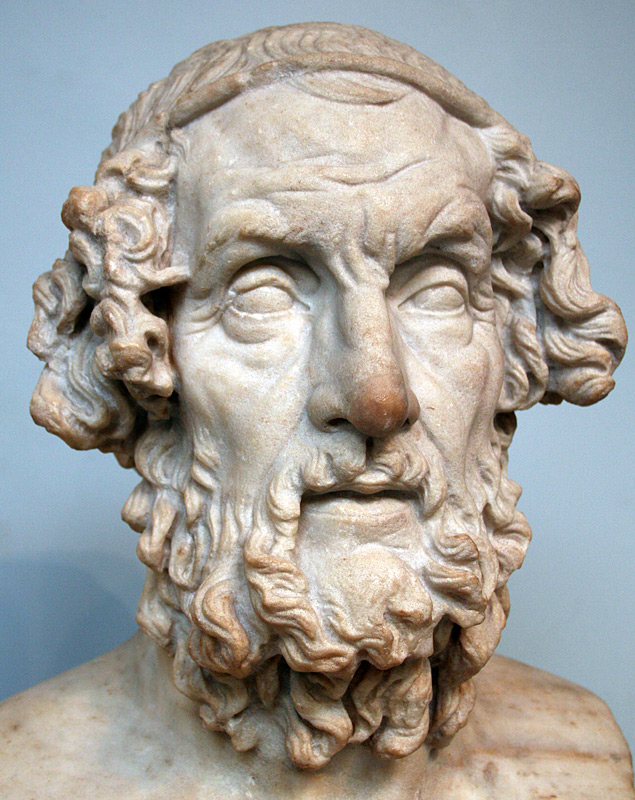

In [ ]:
with open("HomerSculture.jpg", "rb") as f:
    img = f.read()
Image(data=img, width=300)

In [ ]:
print(odiseaHomero[:800])

The Project Gutenberg eBook of The Odyssey
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: The Odyssey

Author: Homer

Translator: Samuel Butler


        
Release date: April 1, 1999 [eBook #1727]
                Most recently updated: December 2, 2023

Language: English

Other information and formats: www.gutenberg.org/ebooks/1727

Credits: Jim Tinsley and David 


---
# **Análisis Exploratorio de los Textos**
---

In [ ]:
docOdisea = nlp(odiseaHomero)
sents = list(docOdisea.sents)
# print(len(sents))

df = pd.DataFrame({
    "idSentence": range(len(sents)),  ##
    "sentence": [sent.text for sent in sents]

})

nSentences = df.shape[0]
dfSize= round(sys.getsizeof(df) / (1024 ** 2), 3)

print(f'Total de lineas sin estructura gramatical: {nSentences} tamano : {round(dfSize,2)} Mb')


Total de lineas sin estructura gramatical: 4487 tamano : 1.29 Mb


# **Distribucion idiomatica y partes del texto como prefacio, capitulos, foot notes y otros**
---

### Con el fin de desagregar el libro por capitulos para futuros analisis se hizo una funcion machGeneratorChapter

In [ ]:
def matchGeneratorChapter(text):

    commentsPattern = re.compile(r'^The Project Gutenberg eBook of The Odyssey', re.IGNORECASE)
    chapterPattern = re.compile(r'^BOOK\s+([IVXLCDM]+)\.?$', re.IGNORECASE)
    footNotesPattern = re.compile(r'^FOOTNOTES\:?', re.IGNORECASE)
    endBookPattern = re.compile(r'\*\*\* END OF THE PROJECT GUTENBERG EBOOK THE ODYSSEY \*\*\*', re.IGNORECASE)

    currentChapter = None
    chapterBuffer = {}

    for line in text.split("\n"):
        line = line.strip()
        if not line:
            continue

        if endBookPattern.match(line):
            break

        chapterMatch = chapterPattern.match(line)
        footNotesMatch = footNotesPattern.match(line)

        if chapterMatch:
            romanNumber = chapterMatch.group(1)
            try:
                currentChapter = roman.fromRoman(romanNumber.upper())
                chapterBuffer[currentChapter] = ""
            except roman.InvalidRomanNumeralError:
                currentChapter = None

        elif footNotesMatch:
          currentChapter = "footnotes"
          if currentChapter not in chapterBuffer:
           chapterBuffer[currentChapter] = ""

        elif currentChapter is not None:
            chapterBuffer[currentChapter] += " " + line

    #Capitulo completo
    data = []

    for chapter, chapterText in chapterBuffer.items():
        docSpacy = nlp(chapterText)

        for sent in docSpacy.sents: # despues del match se paso por spacy para confirmar el idioma.
            texto = sent.text.strip()
            if texto:
                try:
                    idioma = detect(texto)
                except:
                    idioma = "unknown"

                data.append({
                    "chapter": chapter,
                    "sentence": texto,
                    "language": idioma
                })

    return data


In [ ]:
#Data frame desagreado por capitulo, sentence y lenguaje.
df2 = pd.DataFrame(matchGeneratorChapter(odiseaHomero))

In [ ]:
tablaIdiomas = (df2["language"].value_counts().reset_index())
tablaIdiomas.columns = ["Idioma", "Frecuencia"]
tablaIdiomas["Porcentaje (%)"] = (
    tablaIdiomas["Frecuencia"] / tablaIdiomas["Frecuencia"].sum() * 100
).round(2)

def displayLang():
  display(Markdown("###Distribución de Idiomas en *La Odisea* Top 3")) ##
  display(tablaIdiomas[:3])

displayLang()


###Distribución de Idiomas en *La Odisea* Top 3

,Idioma,Frecuencia,Porcentaje (%)
0,en,4283,96.94
1,unknown,35,0.79
2,af,21,0.48


##Tras analisar la prebalencia del idioma  se confirma qu la mayorias de las palabras estan en ingles con un 97% el resto son vocablos minotiratorios de otros idiomas.

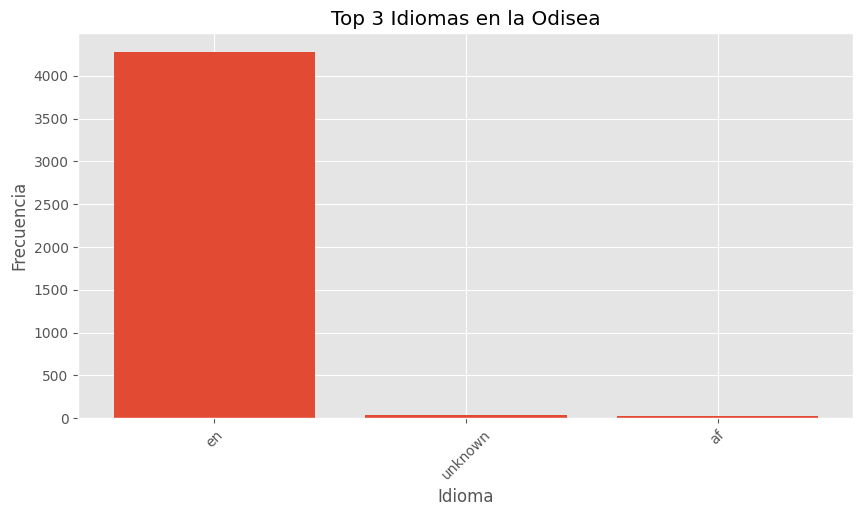

In [ ]:
top3 = tablaIdiomas[:3]

plt.figure(figsize=(10, 5))

plt.bar(top3["Idioma"], top3["Frecuencia"])

plt.title("Top 3 Idiomas en la Odisea")
plt.xlabel("Idioma")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)

plt.show()

#Analisis de frecuencia por capitulo de sentences y palabras
## Con el fin de verificar si hay valores extremos de capitulos mas largos se realizo este analisis.

In [ ]:
df2["chapterStr"] = df2["chapter"].astype(str)

chapterOrder = df2["chapterStr"].drop_duplicates() # Mantener orden original de aparición
chapterCounts = df2["chapterStr"].value_counts() # V2Frecuencia de frases por capítulo
chapterCounts = chapterCounts.reindex(chapterOrder)

docs = list(nlp.pipe(df2["sentence"]))

df2["wordCount"] = [ len([token for token in doc if token.is_alpha])
    for doc in docs]

wordCounts = (
    df2.groupby("chapterStr")["wordCount"]
    .sum()
    .reindex(chapterOrder))

In [ ]:
def chartTable():
  chapterTable = pd.DataFrame({
      "chapter": chapterCounts.index,
      "sentenceFrequency": chapterCounts.values,
      "totalWordCount": wordCounts.values
  })


  totalRow = pd.DataFrame({
      "chapter": ["TOTAL"],
      "sentenceFrequency": [chapterTable["sentenceFrequency"].sum()],
      "totalWordCount": [chapterTable["totalWordCount"].sum()]
  })

  chapterTable = pd.concat([chapterTable, totalRow], ignore_index=True)

  display(chapterTable)

In [ ]:
def graficarMetricas():
  fig, ax = plt.subplots(2, 1, figsize=(12, 8))

  ax[0].bar(chapterCounts.index, chapterCounts.values)
  ax[0].set_title("Sentence Frequency by Chapter")
  ax[0].set_ylabel("Sentence Frequency")
  ax[0].tick_params(axis="x", rotation=90)

  ax[1].bar(wordCounts.index, wordCounts.values)
  ax[1].set_title("Total Word Count by Chapter")
  ax[1].set_ylabel("Total Word Count")
  ax[1].tick_params(axis="x", rotation=90)

  plt.tight_layout()
  plt.show()

In [ ]:
nSentences = df2.shape[0]
dfSize= round(sys.getsizeof(df) / (1024 ** 2), 3)
nSentencesGram = str(len(df2["sentence"]))

print(f'Total de lineas sin estructura gramatical: {nSentences} tamano : {round(dfSize,2)} Mb')
display('Total de sentences con estructura gramatical:', nSentencesGram)

Total de lineas sin estructura gramatical: 4418 tamano : 1.29 Mb


'Total de sentences con estructura gramatical:'

'4418'

## Tabla Numero de sentences y palabras por capitulo

In [ ]:
# chartTable()


### Grafica de Sentences y palabras por capitulo

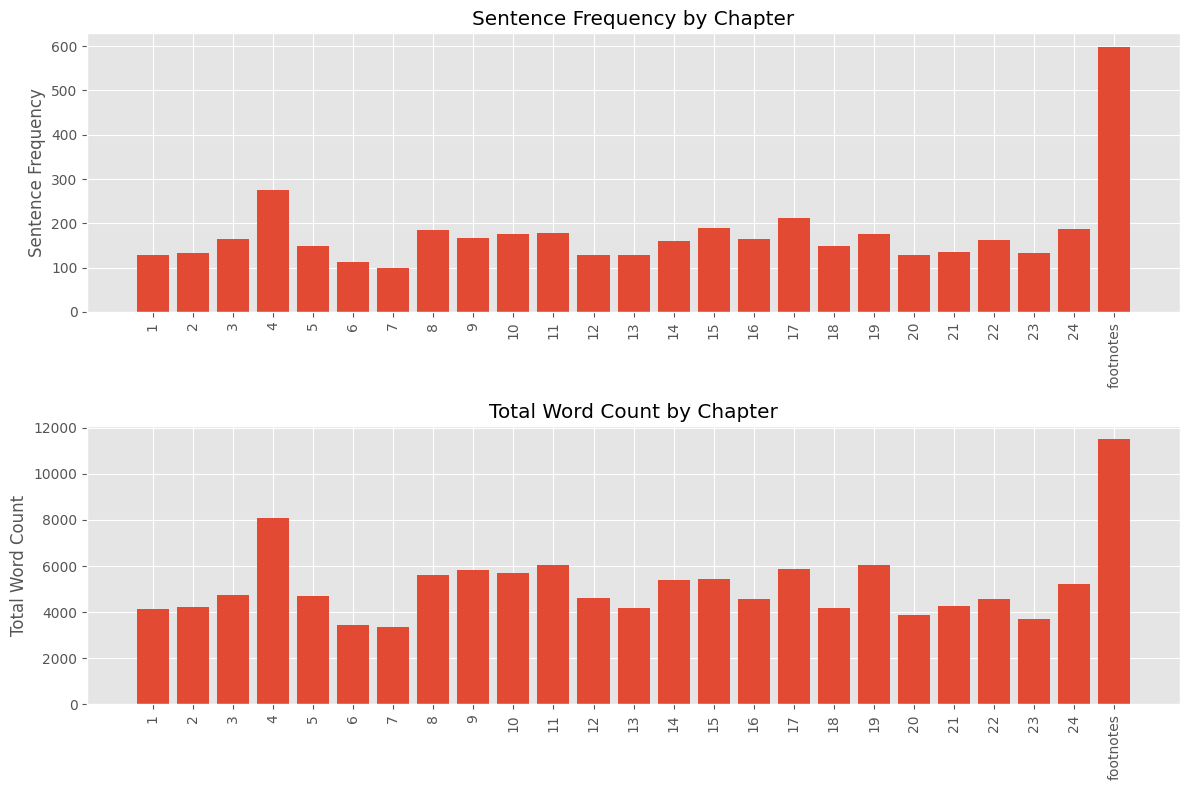

In [ ]:
graficarMetricas()


### Tras verificar la frecuencia de sentences y palabras por capitulos se nota que el capitulo mas largo es el 4, tambien se incluyeron las notas de pie (footnotes) que pueden tener comentarios valiosos para futuros analisis y tiene una frecuencia como valores extremos.

#Histograma del tamano de los texto e Histomgrama TTR

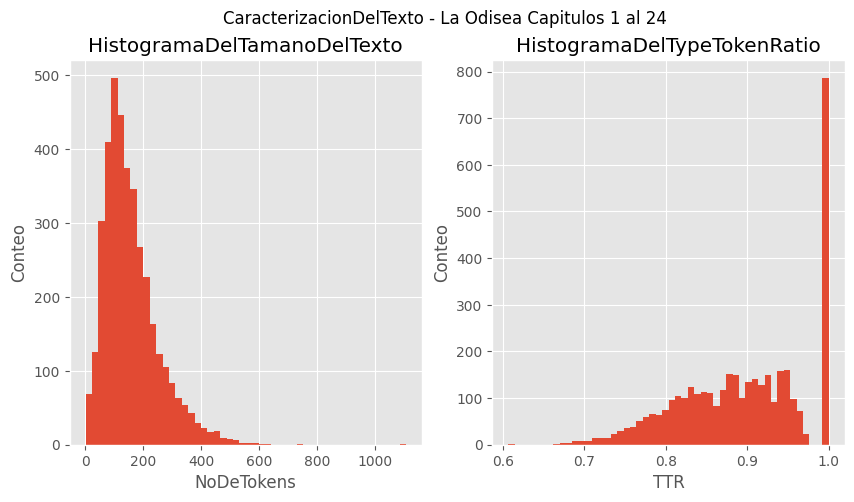

Numero de textos filtrados Capitulo 1 al 24:3819
Longitud media del texto :158.61063105525005


In [ ]:
df2["chapter"] = pd.to_numeric(df2["chapter"], errors="coerce")

# Filtrar solo capitulos del 1 al 24
dfFiltered = df2[
    (df2["chapter"] >= 1) &
    (df2["chapter"] <= 24)
].copy() ##

# Asegurar que no haya NaN en sentence
dfFiltered["sentence"] = dfFiltered["sentence"].fillna("").astype(str)
# Tamaño del texto en numero de tokens
tamanoTexto = dfFiltered["sentence"].map(lambda x: len(x))
# print(tamanoTexto)

# Type-Token Ratio
## TTR = NumeroDePalabrasUnicas / NumeroDePalbrasTotal
typeTokenRatio = dfFiltered["sentence"].map(
    lambda x: len(np.unique(x.split())) / len(x.split())
    if len(x.split()) > 0 else 0
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('CaracterizacionDelTexto - La Odisea Capitulos 1 al 24') ##

ax1.hist(tamanoTexto, bins=50)
ax1.set_title('HistogramaDelTamanoDelTexto')
ax1.set_xlabel('NoDeTokens')
ax1.set_ylabel('Conteo')

ax2.hist(typeTokenRatio, bins=50)
ax2.set_title('HistogramaDelTypeTokenRatio')
ax2.set_xlabel('TTR')
ax2.set_ylabel('Conteo')

plt.show()

print(f'Numero de textos filtrados Capitulo 1 al 24:{len(dfFiltered["sentence"])}')
print(f'Longitud media del texto :{np.mean(tamanoTexto)}')

## Se ve un pico enorme en TTR ≈ 1.0.En muchas oraciones ninguna palabra se repite dentro de la misma oración. A nivel de oración casi no hay repetición léxica como se esperaba bastante diversidad por tratarse de un libro.

In [ ]:
#patrones  ****
pat = re.compile(r"[^a-z ]")
spaces = re.compile(r"\s{2,}")
patIlustracionesW = r"www\S+|\[Illustration\]"
lineasMultiples = re.compile(r'(?:\r?\n)+')

# lineasMultiples= re.compile(r'(\r\n)+') ##
titlePattern = re.compile(r'^[A-Z\s—\-\'’.,:;!?()]+$')
tituloXIPattern = re.compile(r'\b([A-Za-z]+)\.\d+\b')
tituloXXI = """THE TRIAL OF THE AXES, DURING WHICH ULYSSES REVEALS HIMSELF TO EUMAEUS
AND PHILOETIUS"""

#Borrado tag ilustraciones y espacios dobles
fileFilteredIlustrations = re.sub(patIlustracionesW, "", odiseaHomero)
fileFilterMultiLine = re.sub(lineasMultiples, "\n", fileFilteredIlustrations)
fileCorrectTypoChaperXI = re.sub(tituloXIPattern, r'\1.', fileFilterMultiLine)
fileCorrectTypoTituloXXI=  re.sub(re.escape(tituloXXI), tituloXXI + ".", fileCorrectTypoChaperXI)

# print(fileFilterMultiLine)
chapterMatched = matchGeneratorChapter(fileCorrectTypoTituloXXI)



In [ ]:
# display(chapterMatched)

## Funciones de Preprocesamiento

In [ ]:
def preProcessDataChapters():

    sentences = []
    for item in chapterMatched :
        originalSentence = item["sentence"].strip()
        item["isTitle"] = bool(titlePattern.match(originalSentence))
        sentences.append(originalSentence)

    docs = nlp.pipe(sentences, batch_size=500)

    for item, doc in zip(chapterMatched, docs):

        if not item["isTitle"]:
            item["sentenceClean"] = preProcess(doc)
        else:
            item["sentenceClean"] = None

    return chapterMatched

In [ ]:
def preProcess(doc, min_len=1, max_len=23, stopWordsChoice=True, lemmaChoice=False): ##V2 parametrizados stopWords and lemma

    tokens = []

    for token in doc:

        # Filtros estructurales básicos
        if token.is_punct or token.is_space:
            continue
        if not token.is_alpha:
            continue
        if not (min_len <= len(token.text) <= max_len):
            continue
        if stopWordsChoice and token.is_stop:
            continue
        if lemmaChoice:  # lemma, palabra raiz  o texto original
            tokens.append(token.lemma_)
        else:
            tokens.append(token.text)

    text = " ".join(tokens)

    text = unidecode(text).lower() #normailizammos y acentos
    text = re.sub(pat, "", text) #eliminanos caractes especiales
    text = re.sub(spaces, " ", text) #eliminaos espacios duplicados

    return text.strip()


In [ ]:
dataCleaned = preProcessDataChapters()
df3 = pd.DataFrame(dataCleaned);

In [ ]:
# display(dataCleaned)
# display(df3.head())
# display(df3[df3["chapter"] == 10])
# display(df3.columns)

# No se encontraron valores nulos en el data frame.

In [ ]:
total_nan = df3.isnull().sum()
print("Número de valores nulos en el conjunto de datos en el data frame:", total_nan)

Número de valores nulos en el conjunto de datos en el data frame: chapter           0
sentence          0
language          0
isTitle           0
sentenceClean    31
dtype: int64


#Observar de forma anecdótica la diferencia entre la composición de los textos
---



## Se filtrarin los titulos para tener una idea generar de lo que trata cada capitulo.


In [ ]:
dfTitulos = df3[df3["isTitle"]]

dfTitulos = (
    dfTitulos[["chapter", "sentence"]]
    # .sort_values("chapter")
    .reset_index(drop=True)
)

display(dfTitulos)



,chapter,sentence
0,1,THE GODS IN COUNCIL—MINERVA’S VISIT TO ITHACA—...
1,2,ASSEMBLY OF THE PEOPLE OF ITHACA—SPEECHES OF T...
2,3,TELEMACHUS VISITS NESTOR
3,3,AT PYLOS.
4,4,"THE VISIT TO KING MENELAUS, WHO TELLS HIS STOR..."
5,5,CALYPSO—ULYSSES REACHES SCHERIA ON A RAFT.
6,6,THE MEETING BETWEEN NAUSICAA AND ULYSSES.
7,7,RECEPTION OF ULYSSES AT THE PALACE OF KING ALC...
8,8,BANQUET IN THE HOUSE OF ALCINOUS—THE GAMES.
9,9,ULYSSES DECLARES HIMSELF AND BEGINS HIS STORY—...


In [ ]:
# display(df3[df3["chapter"]== "footnotes"])

In [ ]:
def nubePalabras(dataFrame, columna, valor, max_words=20):

    dfFiltrado = dataFrame[
        (dataFrame[columna] == valor) &
        (~dataFrame["isTitle"])
    ]

    text = " ".join(dfFiltrado["sentenceClean"].dropna())

    if not text.strip():
        print(f"{columna} {valor} no contiene texto válido.")
        return

    wordcloud = WordCloud(
        width=800,
        height=800,
        background_color="white",
        max_words=max_words,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(8, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.subplots_adjust(top=0.85)

    # Título secundario (solo si es capítulo)
    if columna == "chapter":
        tituloWrapped = textwrap.fill(
            "\n".join(
                dfTitulos[dfTitulos["chapter"] == valor]["sentence"]
            ),
            width=50
        )
        plt.title(tituloWrapped, fontsize=8)
        plt.suptitle(f"Capítulo {valor}", fontsize=15, color="red", fontweight="bold")

    # Si es acto narrativo
    elif columna == "narrativeAct":
        plt.suptitle(f"Acto {valor}", fontsize=15, color="red", fontweight="bold")

    else:
        plt.suptitle(f"{columna}: {valor}", fontsize=15, fontweight="bold")

    plt.show()

## Se genero una nube de palabras por cada capitulo incluyendo el titulo del capitulo,para observar de forma anecdotica la diferencia entre la composición de los textos respecto a la idea general planteada por el titulo.

In [ ]:
for cap in df3["chapter"].unique().tolist()[::-1]:
  nubePalabras(df3, "chapter", cap, 100)



Output hidden; open in https://colab.research.google.com to view.

### Se incluyeron los actos narrativos segun capitulos para generar la nube de palabras segun acto.

In [ ]:
# display(df3[df3["narrativeAct"]==-1])

In [ ]:
def chapterAct(cap):

    if not isinstance(cap, int):
        return -1
    if int(cap) >= 1 and int(cap) <= 5:
        return 1
    elif int(cap) >= 6 and int(cap) <= 20:
        return 2
    elif int(cap) >= 21 and int(cap) <= 24:
        return 3
    else:
        return -1 #capitulo fuera de rango.

df3.insert(1, "narrativeAct", df3["chapter"].apply(chapterAct))



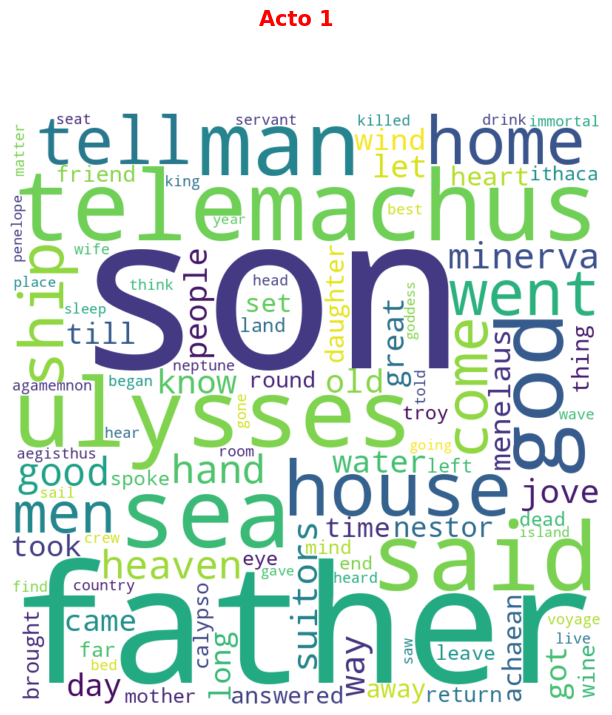

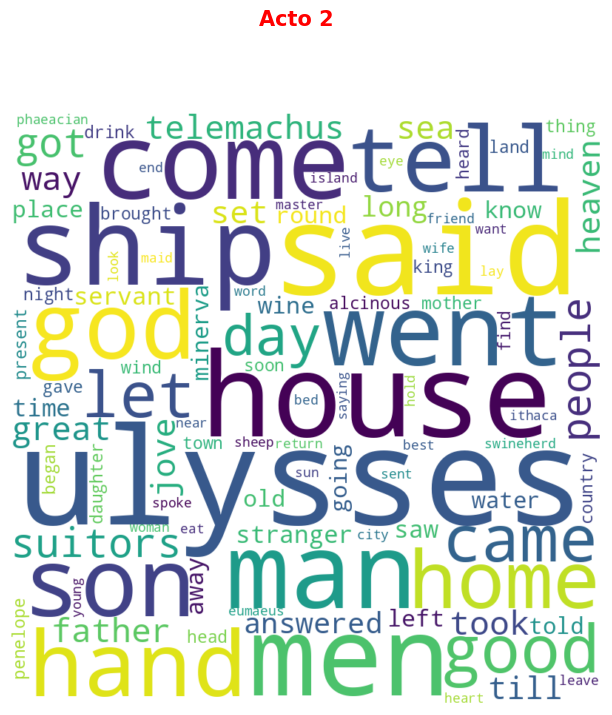

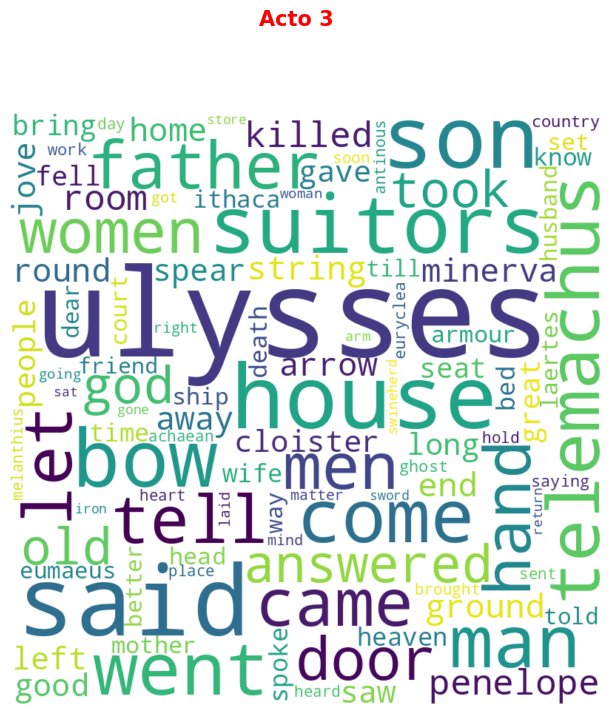

In [ ]:
acts = (df3["narrativeAct"].loc[lambda x: x != -1].unique())

for act in sorted(acts):
    nubePalabras(df3, "narrativeAct", act, 100)

---
##  EMBEDDING
---

In [ ]:
df3["tokens"]= df3["sentenceClean"].dropna().str.split()
df4 = df3[df3["isTitle"]==False].dropna() #Df sin titulos
print(df4["chapter"].isna().sum())

0


In [ ]:
modelFastTextHope = FastText(
    sentences=  df4["tokens"].tolist(),
    vector_size=100,  #se dejo en 100
    epochs = 10, #numero veces re-entrena para aprender OJO! Se cambio de 2 a 10.
    workers = -1,  # Usara todos los procesos (nucleos) disponibles OJO!
    min_count=2, #incluye palabras que se repiten almenos 2 veces
    min_n=3, #Tamano minimo de subPalabras no confundir con min_count OJO.
    max_n= 4, #Tamano maximo de subPalabras a considerar dentro del token
    window=5,
    sg=1, # 1: Skip-Gram  0: CBOW (Tipo de Arquitectura)
)

In [ ]:
def embedingSentence(tokens):  #convierte vectores palabras a sentence
    vectores = [
        modelFastTextHope.wv[word]
        for word in tokens
        if word in modelFastTextHope.wv
    ]

    if len(vectores) == 0: #valida que no haya embeding 0 si no hay un error.
          return np.zeros(modelFastTextHope.vector_size)

    normalizationRaizVector = np.sum(vectores, axis=0) / np.sqrt(len(vectores))
    return normalizationRaizVector



df4["embeddingSentence"] = df4["tokens"].apply(embedingSentence)
# df3[:100].to_csv("datos_sentimientos.csv", index=False, encoding="utf-8")
# display(len(df3))




---
## **Exploración del Embedding**
---


### División de los datos en conjuntos de entrenamiento y prueba

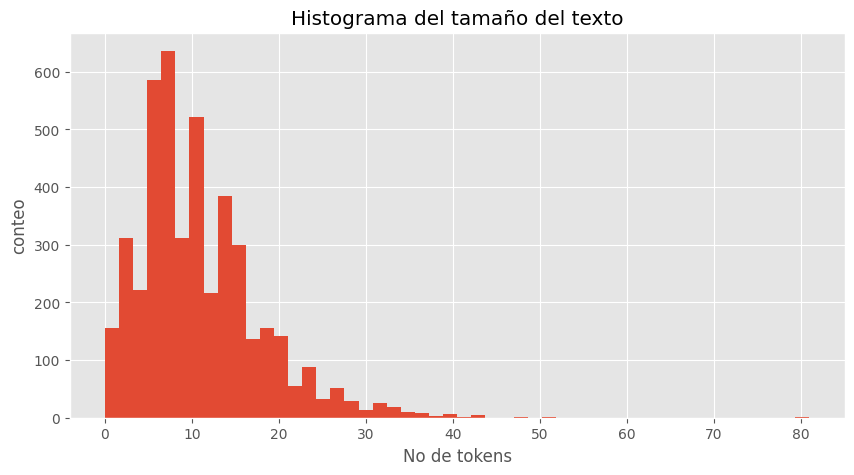

Numero de textos:4455
Longitud media del texto :10.852848101265822


In [ ]:
tamanoTexto = df4["tokens"].map(lambda x: len(x))

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 5))

ax1.hist(tamanoTexto, bins=50)
ax1.set_title('Histograma del tamaño del texto')
ax1.set_xlabel('No de tokens')
ax1.set_ylabel('conteo')

plt.show()

print(f'Numero de textos:{len(df3["tokens"])}')
print(f'Longitud media del texto :{np.mean(tamanoTexto)}')

# Implementacion de un score por sentence.

Se implemento un diccionarios lexicos de sentimientos para obtener las etiquetas para evitar el etiquetado humano y que la muestra sea relevante.

In [ ]:
def sentiScorePerWord(word, posTag="v"):  # pos_tag : 'n' (noun), 'v' (verb), 'a' (adjective), 'r' (adverb)
    synsets = wn.synsets(word, pos=posTag)
    if not synsets:
        return 0.0, 0.0

    synset = synsets[0]  #  primer sentido (simplificación)
    senti_synset = swn.senti_synset(synset.name()) ##V2

    return senti_synset.pos_score(), senti_synset.neg_score()

In [ ]:
def scoreWordPerSentence(tokens):
    pos_total = 0
    neg_total = 0

    for word in tokens:
        pos, neg = sentiScorePerWord(word)
        pos_total += pos
        neg_total += neg

    return pos_total, neg_total

In [ ]:
def sentimentDiscrete(value, threshold=0.05): #Threshold se aumento de 0 a 0.05 valor minimo de umbral para calificar el sentimiento.
    return 1 if value > threshold else 0

df4[["positiveSenti", "negativeSumSenti"]] = df4["tokens"].apply(lambda x: pd.Series(scoreWordPerSentence(x)))
df4["netSenti"] = df4["positiveSenti"] - df4["negativeSumSenti"]
df4["netSentiDiscrete"] = df4["netSenti"].apply(sentimentDiscrete)


In [ ]:
# display(df3.columns)

##Redundancia interna :Grafica de Correlacion




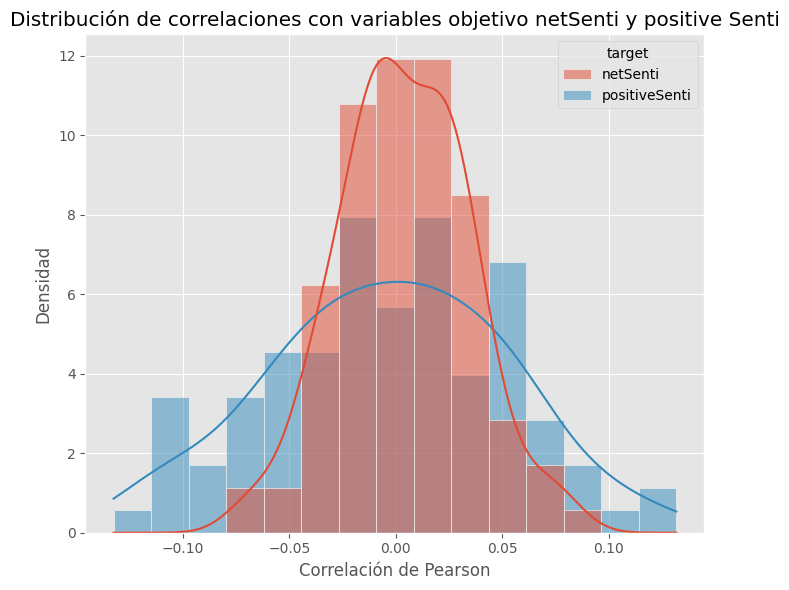

In [ ]:
targets = ["netSenti", "positiveSenti"]
emb = df4["embeddingSentence"].apply(lambda x: np.array(x, dtype=float))

mask = (
    emb.notna()
    & emb.apply(lambda x: x.size > 0)
    & df4[targets].notna().all(axis=1)
)

condicionNoNulos = emb.notna()

condicionNoVacios = emb.apply(lambda x: x.size > 0)

condicionTargetValidos = df4[targets].notna().all(axis=1)

mask = (
    condicionNoNulos
    & condicionNoVacios
    & condicionTargetValidos
)

embValid = emb[mask]
fastTextEmbeding = pd.DataFrame(embValid.tolist(), index=embValid.index)

for t in targets:
    fastTextEmbeding[t] = df4.loc[mask, t].astype(float).values

corrMatFT = fastTextEmbeding.corr(method="pearson")

#  Extraer correlaciones vs cada target
rows = []
for t in targets:
    ft_obj_corr = corrMatFT[t].drop(labels=targets, errors="ignore")
    rows.append(pd.DataFrame({
        "value": ft_obj_corr.values,
        "target": t
    }))

obj_corr = pd.concat(rows, ignore_index=True)

plt.figure(figsize=(7,6))

sns.histplot(
    data=obj_corr,
    x="value",
    hue="target",     # elemento para cambiar color
    kde=True,
    stat="density",
    common_norm=False # importante para que cada curva tenga su propia normalización
)

plt.title("Distribución de correlaciones con variables objetivo netSenti y positive Senti")
plt.xlabel("Correlación de Pearson")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

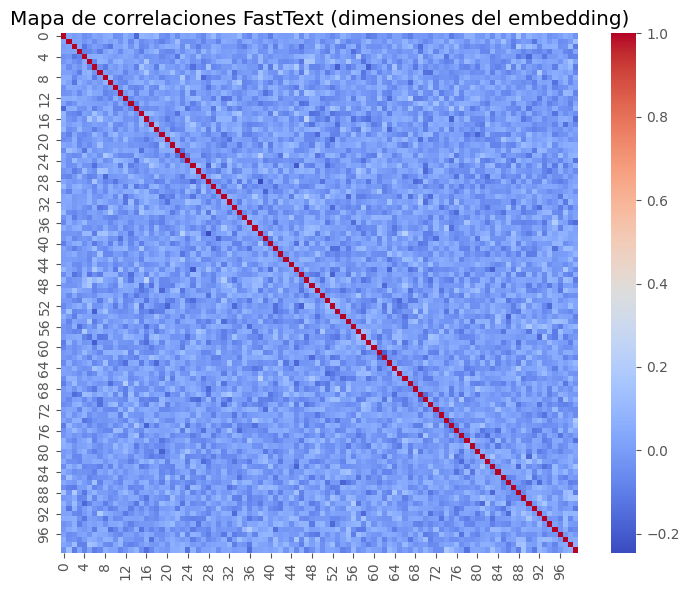

In [ ]:
dfCapitulos = df4[df4["chapter"] != "footnotes"]

emb = dfCapitulos["embeddingSentence"].apply(lambda x: np.array(x, dtype=float))

mask = emb.notna() & emb.apply(lambda x: x.size > 0) # filtra nulos o vectores vacíos
emb = emb[mask]

fasttextEmbedding = pd.DataFrame(emb.tolist(), index=emb.index)#*1

corrMatrixFt = fasttextEmbedding.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corrMatrixFt, annot=False, cmap="coolwarm")
plt.title("Mapa de correlaciones FastText (dimensiones del embedding)")
plt.tight_layout()
plt.show()

En términos comparativos, puede afirmarse que la correlacion del sentimiento neto (netSenti) muestra un patrón de correlación más estable y uniforme, mientras que el sentimiento positvio (positiveSent) evidencia una mayor variabilidad en la intensidad de las asociaciones.

Esta diferencia podría implicar que el modelo FastText captura de manera más consistente la información relacionada con netSenti, en comparación con positiveSenti. Algo para estudiar mas adelante durante el desarrollo del modelo.

###Filtrado de los embeding segun personaje y capitulo

In [ ]:
def filtrarPersonajeChapter(chapter, dataFrame, personaje):

    patPersonaje = re.compile(rf"\b{personaje}\b", re.IGNORECASE)
    dfChapterPersonaje = dataFrame[
        (dataFrame["chapter"] == chapter) &
        (dataFrame["sentence"].str.contains(patPersonaje,regex=True))
    ]
    # print(len(dataFrameFiltradoPersonaje))

    return dfChapterPersonaje

# display(filtrarPersonajeChapter(2,df3,"Ulysses"))

In [ ]:
def filterEmbbending(dfFiltrado):

    if dfFiltrado.empty:
        return None
    embeddings = np.vstack(dfFiltrado["embeddingSentence"].values)
    return np.mean(embeddings, axis=0)



---
#  Entrenamiento del Modelo
---



# Modelo deteccion esperanza por personaje y capitulo.

In [ ]:
def entrenamientoModelo(df4):

    X = np.hstack([                                   #apila embedin verticalmente
        np.vstack(df4["embeddingSentence"].values),   #concatena horizontalmente
        df4[["netSenti"]].values,
        df4[["positiveSenti"]].values,
        df4[["negativeSumSenti"]].values
    ])

    y = df4["netSentiDiscrete"]

    xTrain, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    modeloEsperanza = LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )

    modeloEsperanza.fit(xTrain, y_train)

    y_pred = modeloEsperanza.predict(X_test)  #70% 30%

    silhouette = silhouette_score(X, y)
    davies = davies_bouldin_score(X, y)

    reporte = classification_report(y_test, y_pred)

    metricas = {
        "silhouette": silhouette,
        "davies_bouldin": davies,
        "classification_report": reporte
    }

    return y_test, y_pred, modeloEsperanza, metricas

In [ ]:
y_test, y_pred, modeloEsperanza, metricas = entrenamientoModelo(df4)

print(f"Silhouette Score      : {metricas['silhouette']:.4f}")
print(f"Davies-Bouldin Index  : {metricas['davies_bouldin']:.4f}")
print(metricas["classification_report"])

Silhouette Score      : 0.3238
Davies-Bouldin Index  : 1.1836
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       625
           1       0.97      1.00      0.99       260

    accuracy                           0.99       885
   macro avg       0.99      0.99      0.99       885
weighted avg       0.99      0.99      0.99       885



###El valor de F1-Score es bastante alto que puede ser  generado por el hecho que las etiquetas no son humanas, algo para mejorar en el modelo pues indica un bias de autoentrenamiento.
###Con un valore de Silhouette score de 0.32 se ve que ha cierto agrupamiento moderado de los clusters.
###Asi mismo con valores de Davis score cercanos a 1 deja verr que debe haber cierto agrupamiento entre los closters.


In [ ]:
# filtrarPersonajeChapter(4, df4,"Ulysses")

In [ ]:
def detectarEsperanzaChapter(chapter, df, personaje):

    dfFiltrado = filtrarPersonajeChapter(chapter, df, personaje)

    if dfFiltrado.empty: #personaje no aparece :(
        return 0.0
    embedding = filterEmbbending(dfFiltrado)
    if embedding is None:
        return 0.0

    #Se realizo un promedio para poder ponderar mas la probabilidad.
    netSentiMean = dfFiltrado["netSenti"].mean()
    positiveMean = dfFiltrado["positiveSenti"].mean()
    negativeMean = dfFiltrado["negativeSumSenti"].mean()

    features = np.hstack([
        embedding,
        netSentiMean,
        positiveMean,
        negativeMean
    ])

    features = features.reshape(1, -1)  #Ajusta al formato scikitlearn espera que los datos sean de la forma (NSamples, nFeatures) entonces
                                                #por eso se hace un reshape (100,)  =>  (1,100)

    prob = modeloEsperanza.predict_proba(features)[0][1] #probailidad de una clase [[P(NoEsperanza) , P(Esperanza)]]

    return float(prob)

In [ ]:
def graficaDeEsperanzaPersonaje(personaje):
  dfResults = pd.DataFrame([
      {
          "chapter": i,
          "esperanza": detectarEsperanzaChapter(i, df4, personaje)
      }
      for i in range(1, 25)
  ])

  plt.figure()

  plt.plot(
      dfResults["chapter"],
      dfResults["esperanza"],
      marker="o"
  )

  plt.xticks(range(1, 25))

  plt.xlabel("Capítulo")
  plt.ylabel("Esperanza (Score)")
  plt.title(f"Evolución de Esperanza (Sentimiento Positivo) por Capítulo - {personaje}")

  plt.grid(True)

  plt.show()

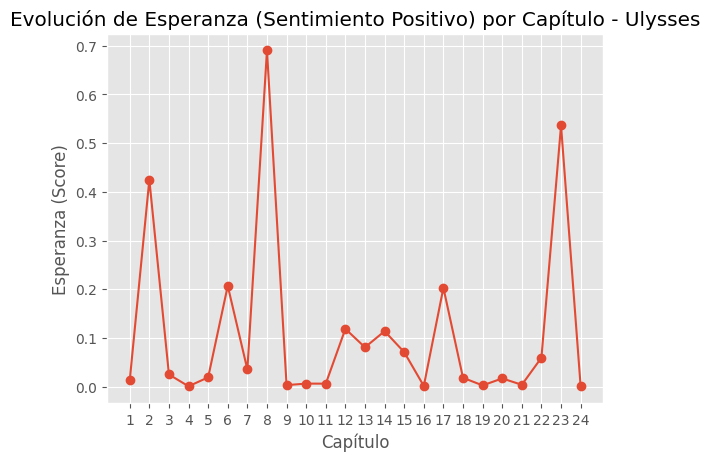

In [ ]:
graficaDeEsperanzaPersonaje("Ulysses")

#<center>

# Modelo sentimiento dirigido personaje "A" hacia personaje "B"  del libro la odisea

### A -> B (Action)

</center>

---

Durante la extracción de tripletas se normalizan sujetos y objetos (ejemplo. "hijo de Ularte", "Odysseus" =>  ulysses) para que todas las interacciones A→B se agrupen correctamente.Estos se almacenaron el el dicionario epitetosDic.json



Cuando se detecta la acción en la tripleta (A, verbo, B), el peso del verbo se usa para calcular levelAccion, que determina si la relación es ayuda, castiga/obstaculiza o neutra. Estos se almacenaron el el dicionario verbWeights.json.

Muchos de las interaciones dirigidas A -> B no aparece con los nombres propios de los personajes, si no con pronombres personales como el (he), ella (she), de el (him) etc; Por lo cual se reemplazan por la entidad correspondiente para recuperar correctamente la relación dirigida A→B. Para esto se incluyerion un dicionario de genero que se almacenaron en genderDic.json.

#### Abrimos los Json de los diccionarios.

In [ ]:
with open("verbWeights.json", "r", encoding="utf-8") as f:
    verbWeights = json.load(f)

with open("genderDic.json", "r", encoding="utf-8") as f:
    genderDic = json.load(f)

with open("epitetosDic.json", "r", encoding="utf-8") as f:
    epitetosDic = json.load(f)

### Funciones de Preprocesamiento y Limpieza

In [ ]:
def cleaningDf(df):
  dfLimpio = df.drop(columns=['language','tokens'])
  dfLimpio = dfLimpio[dfLimpio["chapter"]!= "footnotes"]
  dfLimpio["sentence"] = dfLimpio["sentence"].str.lower()
  corpus = dfLimpio["sentence"].tolist()
  return dfLimpio, corpus


In [ ]:
def preProcessDfOraciones(df, punto=True, exclamacionSplit=False, interrogacionSplit=False):

    signos = ""

    if punto:
        signos += r"\."
    if exclamacionSplit:
        signos += r"\!"
    if interrogacionSplit:
        signos += r"\?"

    filas = []

    for _, row in df.iterrows():
        chapter = row["chapter"]
        text = str(row["sentenceClean"])

        # decidir si dividir o no
        if signos == "":
            sentences = [text]
        else:
            pattern = rf"(?<=[{signos}])\s+"
            sentences = re.split(pattern, text)

        for s in sentences:
            filas.append({
                "sentence": s,
                "chapter": chapter
            })

    return pd.DataFrame(filas)

##Funciones de extraccion de tripletas Personaje A - Personaje B (Accion)
(Usando dependencias sintaticas. )

En este trabajo se decidió no eliminar las stopwords, ya que el pipeline de extracción se basa en dependencias sintacticas obtenidas mediante spaCy como **nsubj** (Nominal Subject), **dobj** (Direct Object), **pobj** (Preposition Object)  y **attr**(Atributo del sugeto normalente un verbo), las cuales dependen de la estructura completa de la oración.

Por esta razón, se opto por mantenerlas durante el procesamiento, ya que su eliminación podria alterar la estructura gramatical y afectar la correcta identificación de las relaciones entre entidades de las tripletas.


Para decterar las tripletas se una representacion dirigida entre dos entidades (A -> B) junto a una accion (verbo) y un contexto.

In [ ]:
def extraerTripletasAactionB( dfOraciones,epitetosDic,verbWeights,genderMap,objectPasiveVoice=False,personalPronouns=False):

    tripletas = []

    setPersonajes = set(epitetosDic.keys())

    for _, row in dfOraciones.iterrows():
        sentence = row["sentence"]
        chapter = row["chapter"]

        doc = nlp(sentence)
        lastEntity = None

        for token in doc:
            if token.pos_ == "VERB" and token.tag_.startswith("VB"):

                sujeto = None
                objeto = None

                for child in token.children:   # buscar sujeto
                    if child.dep_ in ("nsubj", "nsubjpass"):
                        sujeto = child.text.lower()

                for child in token.children:
                    if child.dep_ in ("dobj", "pobj", "attr"):   # buscar objeto
                        objeto = child.text.lower()

                if personalPronouns:                 # resolver pronombres
                    if sujeto in genderMap:
                        sujeto = genderMap[sujeto]
                    if objeto in genderMap:
                        objeto = genderMap[objeto]

                for canonical, aliases in epitetosDic.items():   # normalizar epitetos
                    if sujeto in aliases:
                        sujeto = canonical
                    if objeto in aliases:
                        objeto = canonical

                if sujeto and sujeto not in genderMap:                 # guardar ultina entidad válida
                    lastEntity = sujeto

                if personalPronouns: # resolver he/she
                    if sujeto in ("he", "she") and lastEntity:
                        sujeto = lastEntity
                    if objeto in ("him", "her") and lastEntity:
                        objeto = lastEntity

                if not sujeto:         #   filtrado
                    continue

                #  extricto setPersonajes
                if not objectPasiveVoice:
                    if objeto not in setPersonajes:
                        continue

                # libre cualquier objeto
                if objectPasiveVoice and not objeto:
                    continue

                if sujeto != objeto: #Generacion de tripletas :) Porfin!!!
                    tripletas.append({
                        "a": sujeto,
                        "accion": token.lemma_.lower(),
                        "b": objeto,
                        "chapter": chapter
                    })

    return pd.DataFrame(tripletas)

## Funciones de asignacion de nivel de accion (level Accion) segun dicionario de verbos.

In [ ]:
def asignarLevelAccion(dfTripletas, verbWeights):

    dfTripletas["levelAccion"] = dfTripletas["accion"].apply(
        lambda v: verbWeights[v] if v in verbWeights else None
    )

    dfTripletas = dfTripletas.dropna(subset=["levelAccion"]) # Eliminar verbos fuera del diccionario

    return dfTripletas

##Funciones de embedding
Convertir las tripletas en vectores semanticos usando el modelo de fastText

In [ ]:
def sentenceVector(model, text):
    tokens = tokenizador(text)
    vectors = [model.wv[w] for w in tokens if w in model.wv]

    if not vectors:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [ ]:
def construirEmbeddingsTripletas(dfTripletas, model):

    dim = model.vector_size

    vectores = np.zeros((len(dfTripletas), dim * 3))

    for i, row in enumerate(dfTripletas.itertuples()):

        a = row.a
        v = row.accion
        b = row.b

        vecA = model.wv[a] if a in model.wv else np.zeros(dim)
        vecV = model.wv[v] if v in model.wv else np.zeros(dim)
        vecB = model.wv[b] if b in model.wv else np.zeros(dim)

        vectores[i] = np.concatenate([vecA, vecV, vecB])

    return vectores

### Funciones de entranamiento fastText

FastText se utiliza para aprender representaciones vectoriales del texto del corpus.

In [ ]:
def tokenizador(text):
    text = str(text).lower()
    text = re.sub(r"[^a-záéíóúüñ0-9_\s]", " ", text) #eliminamos caracter no permitidos que no sea alfa, tildes, numeros, espacios o _
    text = re.sub(r"\s+", " ", text).strip() #revision de espacios vacios uno o mas
    return text.split()

def entrenarFastText(corpus, vectorSize=200, window=5, minCount=2, epochs=25):
    tokenized = [tokenizador(t) for t in corpus]

    model = FastText(
        sentences=tokenized,
        vector_size=vectorSize,
        window=window,
        min_count=minCount,
        workers=4,
    )

    model.train(tokenized, total_examples=len(tokenized), epochs=epochs)
    return model

el modelo de regresión SVR utiliza estas representaciones como variables de entrada para predecir cuantitativamente el nivel de accion verbal narrativa.

In [ ]:
def entrenarRegresorLevelAccion(x, y):

    xTrain, xTest, yTrain, yTest = train_test_split(
        x, y, test_size=0.2, random_state=42
    )
    regresor = SVR(kernel="rbf", C=3.0, epsilon=0.05) #Support Vector Regression,
    regresor.fit(xTrain, yTrain)
    yPred = regresor.predict(xTest)

    metricas = {
        "mae": mean_absolute_error(yTest, yPred),
        "mse": mean_squared_error(yTest, yPred),
        "rmse": np.sqrt(mean_squared_error(yTest, yPred)),
        "r2": r2_score(yTest, yPred)
    }

    return regresor, metricas, yTest, yPred

##Funciones de clasificacion tipo de relacion (ayuda, neutra, casitga/obstaculiza) y calibracion.

In [ ]:
def calibraDatosNeutro(levelAccion):
    limiteSeparacionValoresNeutros = 0.15
    return levelAccion.abs().quantile(limiteSeparacionValoresNeutros)

In [ ]:
def categorizarTipoRelacion(levelAccion, theta):
    if levelAccion > theta:
        return "ayuda"
    elif levelAccion < -theta:
        return "castigaObstaculiza"
    else:
        return "neutra"

## Funcion pipeline completo

In [ ]:
def ejecutarPipelineML(
        df,
        epitetosDic,
        verbWeights,
        genderDic,
        fasttextModel,
        objectPasiveVoice=False,
        personalPronouns=True,
        ):

    # Preprocess
    dfOraciones = preProcessDfOraciones(df)

    # Tripletas
    dfTripletas = extraerTripletasAactionB(
        dfOraciones,
        epitetosDic,
        verbWeights,
        genderDic,
        objectPasiveVoice,
        personalPronouns
    )

    if dfTripletas.empty:
        raise ValueError("no se detectaron tripletas")

    # determinacion levelAccion inicial

    dfTripletas["levelAccion"] = dfTripletas["accion"].map(verbWeights)

    dfTrain = dfTripletas.dropna(subset=["levelAccion"])

    if dfTrain.empty:
        raise ValueError("no hay datos para entrenar")


    #  embeddings
    Xtrain = construirEmbeddingsTripletas(dfTrain, fasttextModel)
    ytrain = dfTrain["levelAccion"].values

    #  entrenar modelo
    regresor, metricas, yTest, yPred = entrenarRegresorLevelAccion(
        Xtrain,
        ytrain,
    )
    #  embeddings para TODAS las tripletas
    Xall = construirEmbeddingsTripletas(dfTripletas, fasttextModel)

    predicciones = regresor.predict(Xall)

    #  combinar reglas + ML
    dfTripletas["levelAccion"] = dfTripletas["accion"].map(verbWeights)

    mask = dfTripletas["levelAccion"].isna()

    dfTripletas.loc[mask, "levelAccion"] = predicciones[mask]

    # calibracion neutra
    theta = calibraDatosNeutro(dfTripletas["levelAccion"])

    dfTripletas["tipoRelacion"] = dfTripletas["levelAccion"].apply(
        lambda v: categorizarTipoRelacion(v, theta)
    )

    # clustering sobre embeddings
    k = 5
    clusterModel = KMeans(n_clusters=k, random_state=42)

    labelsClusters = clusterModel.fit_predict(Xall)
    scoreSil = silhouette_score(Xall, labelsClusters)
    scoreDavies = davies_bouldin_score(Xall, labelsClusters)

    return {
        "dfOraciones": dfOraciones,
        "dfTripletas": dfTripletas,
        "modelo": regresor,
        "metricas": metricas,
        "theta": theta,
        "Xtrain": Xtrain,
        "ytrain":ytrain,
        "yTest": yTest,
        "yPred": yPred,
         "scoreSil": scoreSil,
        "scoreDavies": scoreDavies,
        "labelsClusters": labelsClusters
    }

# Correr modelo

___

In [ ]:
df4_2 , corpus = cleaningDf(df3)
fasttextModel = entrenarFastText(corpus, vectorSize=150)
resultado = ejecutarPipelineML(df4_2, epitetosDic, verbWeights, genderDic,fasttextModel,objectPasiveVoice=True, personalPronouns=False)
# print(resultado["metricas"]))
dfTripletas = resultado["dfTripletas"]
# print(resultado["dfTripletas"]["levelAccion"].unique())
print(resultado["dfTripletas"]["tipoRelacion"].value_counts())

tipoRelacion
castigaObstaculiza    1226
ayuda                  646
neutra                 444
Name: count, dtype: int64


In [ ]:
print("-"*50)
print("Numero de isna en df4 Chapter :", df4["chapter"].isna().sum() )

verbosNeutros = dfTripletas[dfTripletas["tipoRelacion"] == "neutra"]["accion"].unique()

# print("Verbos neutros:")
# print(sorted(verbosNeutros))
print("Total verbos neutros          :", len(verbosNeutros))
print("Total verbos únicos           :", dfTripletas["accion"].nunique())
verbosNoEnDiciionarip = dfTripletas[
    ~dfTripletas["accion"].isin(verbWeights.keys())
]["accion"].nunique()

print("Verbos NO en verbWeights      :", verbosNoEnDiciionarip)
print("Antes de filtrar dfTripletas  :", len(dfTripletas))
dfTemp = dfTripletas[dfTripletas["accion"].isin(verbWeights.keys())]
print("Despues de filtrar dfTripletas que tienen  accion:", len(dfTemp))
print("-"*50)

--------------------------------------------------
Numero de isna en df4 Chapter : 0
Total verbos neutros          : 17
Total verbos únicos           : 603
Verbos NO en verbWeights      : 549
Antes de filtrar dfTripletas  : 2316
Despues de filtrar dfTripletas que tienen  accion: 886
--------------------------------------------------


In [ ]:
# print(resultado["df4_2Tripletas"]["accion"].value_counts())
df4_2Ulysses = df4_2[df4_2["sentenceClean"].str.contains("ulysses", case=False, na=False)]
tabla = df4_2Ulysses.groupby("chapter").size().reset_index(name="frecuencia")

display(tabla.head())

,chapter,frecuencia
0,1,16
1,2,17
2,3,7
3,4,17
4,5,27


# Silhouette and Daviews score:

In [ ]:
print("Silhouette score :", resultado["scoreSil"])
print("Davies score     :", resultado["scoreDavies"])

Silhouette score : 0.15176232169272103
Davies score     : 2.1042100269345254


Los valores silhoutte score son &lt;0.5 lo que puede considerarse bueno.
Adicionalmente los valores de Davies score esta &gt;1 lo que puede tamnbien considerarse bueno.

In [ ]:
texts = [simple_preprocess(s) for s in corpus]
dictionary = Dictionary(texts)
bowCorpus = [dictionary.doc2bow(t) for t in texts]

ldaModel = LdaModel(
    bowCorpus,
    id2word=dictionary,
    num_topics=5,
    passes=10
)

perplexity = ldaModel.log_perplexity(bowCorpus)


coherenceModel = CoherenceModel(
    model=ldaModel,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

scoreCoherence = coherenceModel.get_coherence()

print("Coherence score:", scoreCoherence)
print("Perplexity:", perplexity)


Coherence score: 0.49883272608706564
Perplexity: -6.471986859755192


Se puede interpretar que el score de coherencia es aproximadamente 0.5 que es aceptable donde los topicos tiene coherencia semantica lo que se espera del libro que habla de un mismo tema, heroismo, viaje etc.

Para un valor negativo de perplexity(que tan sorprendido esta el modelo) de -6.4 quiere decir que el modelo predice bien las palabras.


## Histograma tipo de ralacion ayuda, neutro o castiga/obstaculiza en todo el libro.

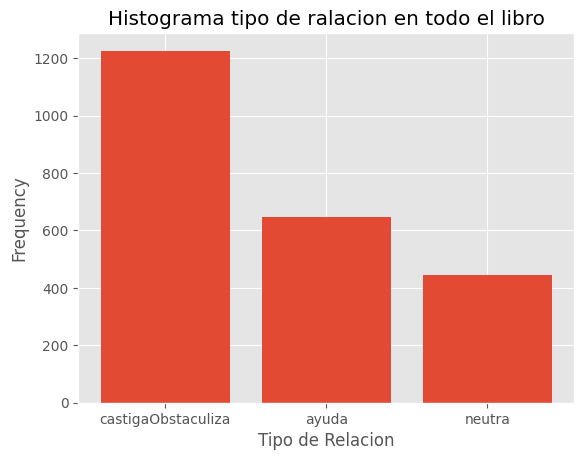

In [ ]:
dfTripletas = resultado["dfTripletas"]

conteoRelaciones = dfTripletas["tipoRelacion"].value_counts()

plt.figure()
plt.bar(conteoRelaciones.index, conteoRelaciones.values)
plt.title("Histograma tipo de ralacion en todo el libro")
plt.xlabel("Tipo de Relacion")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()

#Histograma de frecuencias interaciones entre caracteres A -> B

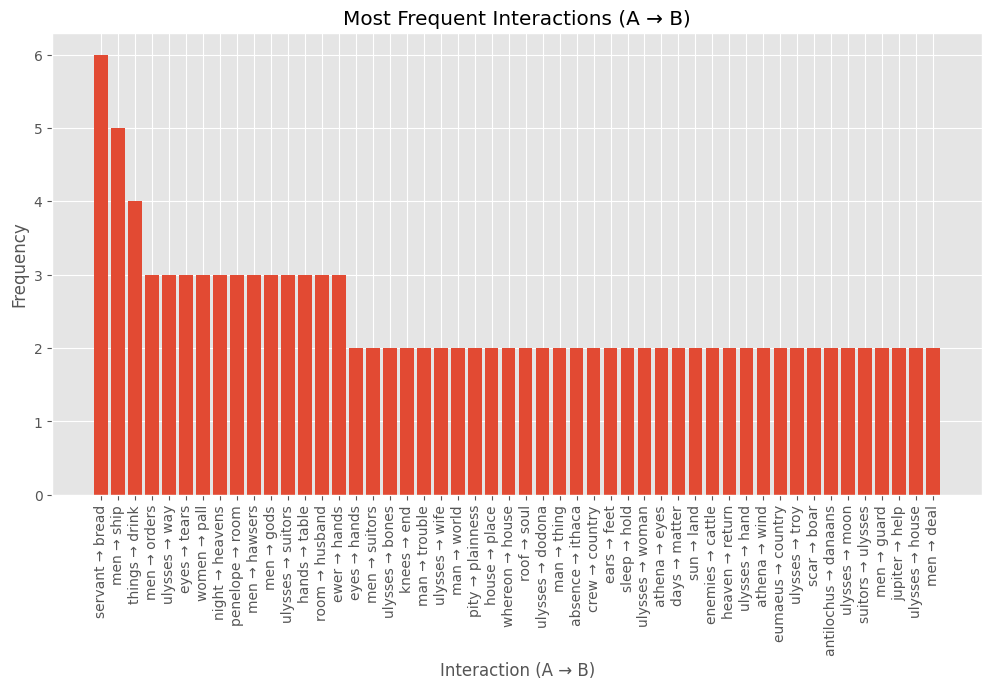

In [ ]:
dfTripletas = resultado["dfTripletas"].copy()

dfTripletas["interaccion"] = dfTripletas["a"] + " → " + dfTripletas["b"]

frecuencias = dfTripletas["interaccion"].value_counts()

# Solo las 20 más abundantes
topFrecuencias = frecuencias.head(50)

plt.figure(figsize=(12,6))
plt.bar(topFrecuencias.index, topFrecuencias.values)
plt.title("Most Frequent Interactions (A → B)")
plt.xlabel("Interaction (A → B)")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# print("-"*50)
# print(frecuencias[:80])
# print("-"*50)

In [ ]:
# display(dfTripletas)

#Histograma  tipo de Relación por Capitulo libro La Odisea

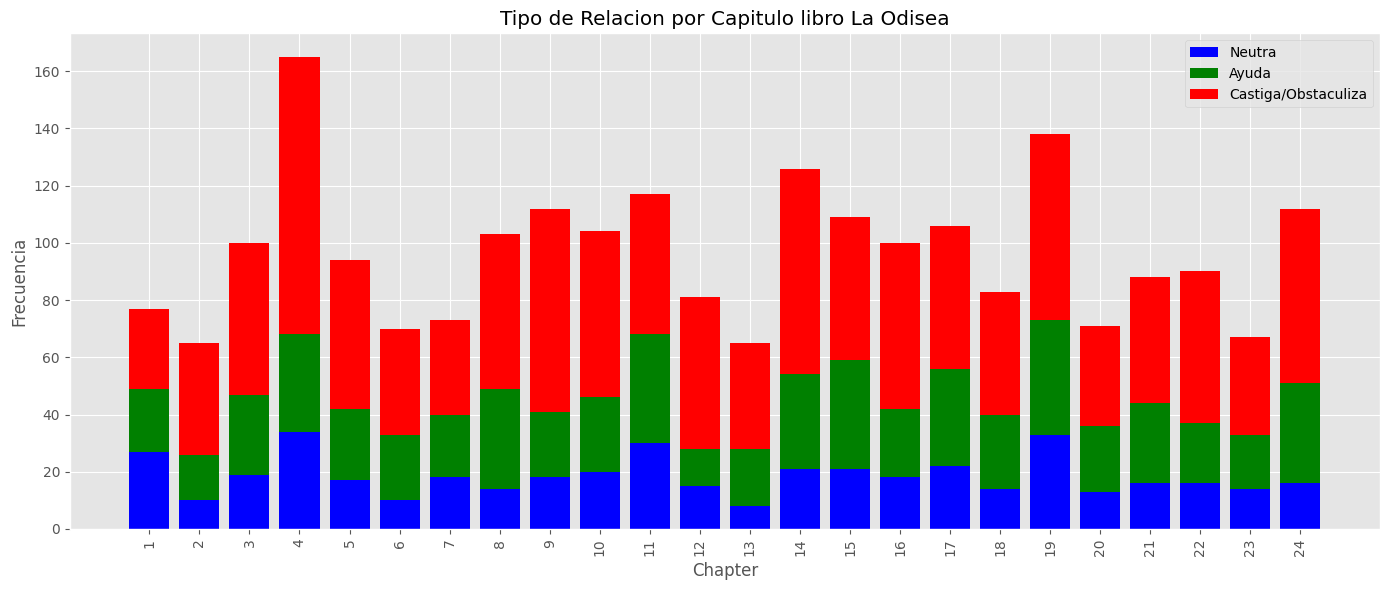

In [ ]:
dfTripletas["chapter"] = pd.to_numeric(dfTripletas["chapter"], errors="coerce")

dfResumenCapitulos = (
    dfTripletas
    .groupby(["chapter", "tipoRelacion"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# asegurar columnas aunque no existan en algún capítulo
for col in ["ayuda", "castigaObstaculiza", "neutra"]:
    if col not in dfResumenCapitulos:
        dfResumenCapitulos[col] = 0

dfResumenCapitulos = dfResumenCapitulos.sort_values("chapter")

plt.figure(figsize=(14,6))

plt.bar(
    dfResumenCapitulos["chapter"],
    dfResumenCapitulos["neutra"],
    color="blue",
    label="Neutra"
)

plt.bar(
    dfResumenCapitulos["chapter"],
    dfResumenCapitulos["ayuda"],
    bottom=dfResumenCapitulos["neutra"],
    color="green",
    label="Ayuda"
)

plt.bar(
    dfResumenCapitulos["chapter"],
    dfResumenCapitulos["castigaObstaculiza"],
    bottom=dfResumenCapitulos["neutra"] + dfResumenCapitulos["ayuda"],
    color="red",
    label="Castiga/Obstaculiza"
)

plt.xticks(
    dfResumenCapitulos["chapter"],
    dfResumenCapitulos["chapter"],
    rotation=90
)

plt.xlabel("Chapter")
plt.ylabel("Frecuencia")
plt.title("Tipo de Relacion por Capitulo libro La Odisea")
plt.legend()
plt.tight_layout()
plt.show()

# Tabla
# dfResumenCapitulos

## Histograma de frecuencias interaciones con Ulyses(Odiseo) por capitulo y tipo de Relacion.



In [ ]:
def graficarInteracciones(
        dfTripletas,
        personajeA="ulysses",
        personajeB=None,
        mostrarConQuien=False,
        loveVerbs=False):

    loveVerbSet = {
        "love","care","long","desire","yearn",
        "weep","embrace","adore","mourn","miss"
    }

    df = dfTripletas.copy()
    df["chapter"] = pd.to_numeric(df["chapter"], errors="coerce")
    df["a"] = df["a"].str.lower()
    df["b"] = df["b"].str.lower()

    personajeA = personajeA.lower()

    if personajeB is not None:
        personajeB = personajeB.lower()

    # Filtro personajes
    if personajeB is None:
        mask = (df["a"] == personajeA) | (df["b"] == personajeA)
        dfA = df.loc[mask].copy()
    else:
        dfA = df[
            ((df["a"] == personajeA) & (df["b"] == personajeB)) |
            ((df["a"] == personajeB) & (df["b"] == personajeA))
        ].copy()

    if dfA.empty:
        print("No hay interacciones encontradas")
        return None

    # Filtro verbos amor
    if loveVerbs:
        dfA = dfA[dfA["accion"].isin(loveVerbSet)]

    # Grafica A <=> B
    if personajeB is not None:

        chapters = sorted(dfTripletas["chapter"].dropna().unique())

        dfCount = (
            dfA.groupby("chapter")
               .size()
               .reindex(chapters, fill_value=0)
               .reset_index(name="interacciones")
        )

        plt.figure(figsize=(12,6))
        plt.bar(dfCount["chapter"], dfCount["interacciones"])
        plt.xticks(dfCount["chapter"], rotation=90)
        plt.xlabel("Chapter")
        plt.ylabel(f"{personajeA} ↔ {personajeB}")
        plt.title(f"Interacciones entre {personajeA} y {personajeB}")

    # Grafica personaje A
    else:

        if not mostrarConQuien:

            dfResumen = (
                dfA.groupby(["chapter","tipoRelacion"])
                   .size()
                   .unstack(fill_value=0)
                   .reindex(columns=["neutra","ayuda","castigaObstaculiza"], fill_value=0)
                   .sort_index()
            )

            plt.figure(figsize=(14,6))

            plt.bar(dfResumen.index, dfResumen["neutra"], label="Neutra")

            plt.bar(
                dfResumen.index,
                dfResumen["ayuda"],
                bottom=dfResumen["neutra"],
                label="Ayuda"
            )

            plt.bar(
                dfResumen.index,
                dfResumen["castigaObstaculiza"],
                bottom=dfResumen["neutra"] + dfResumen["ayuda"],
                label="Castiga / Obstaculiza"
            )

            plt.title(f"Interacciones de {personajeA} por Capítulo")

            # ESTA ERA LA LINEA QUE FALTABA
            plt.legend(title="Tipo de relación")

        else:

            dfA["conQuien"] = np.where(
                dfA["a"] == personajeA,
                dfA["b"],
                dfA["a"]
            )

            dfResumen = (
                dfA.groupby(["chapter","conQuien","tipoRelacion"])
                   .size()
                   .reset_index(name="freq")
            )

            dfPivot = dfResumen.pivot_table(
                index="chapter",
                columns=["conQuien","tipoRelacion"],
                values="freq",
                fill_value=0
            ).sort_index()

            dfPivot.plot(kind="bar", stacked=True, figsize=(14,6))

            plt.title(f"Interacciones de {personajeA} con otros personajes")

            plt.legend(
                title="Personaje / Tipo Relación",
                bbox_to_anchor=(1.05,1)
            )

    plt.xlabel("Chapter")
    plt.ylabel("Frecuencia de Interacciones")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    print("Total interacciones:", len(dfA))

    return

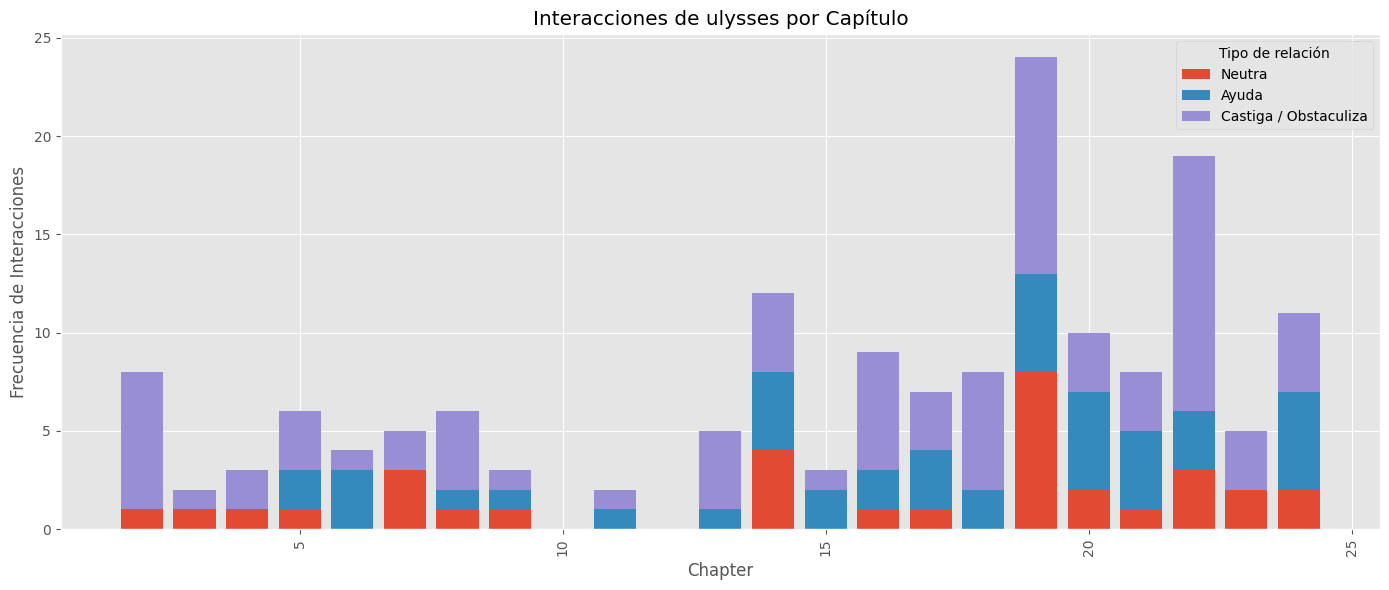

Total interacciones: 160


In [ ]:
# graficarInteracciones(dfTripletas,"ulysses",mostrarConQuien=True)
graficarInteracciones(dfTripletas,"ulysses",mostrarConQuien=False)

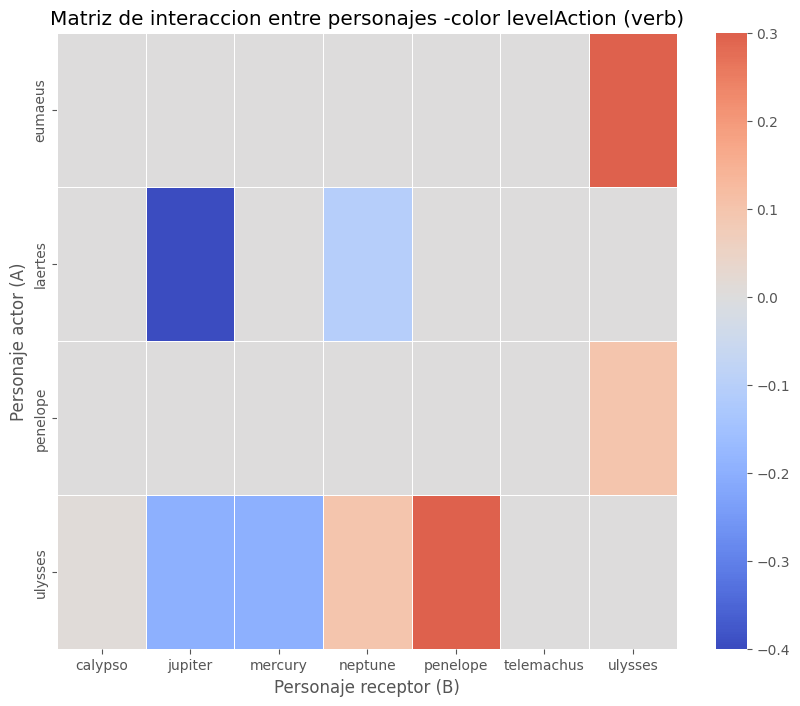

Numero de personajes detectados en A: 837
Numero de personajes detectados en B: 990
Numero de personajes en diccionario: 16
Numero de personajes que hacen match con el dicionario en A: 14
Numero de personajes que hacen match con el dicionario en B: 12
Numero de tripletas originales: 2316
Numero de tripletas despues del filtrado: 11
Numero de personajes que interactuan: 9
Numero de personajes del diccionario sin interaccion: 7
Personajes sin interaccion: ['aeolus', 'anticlea', 'athena', 'circe', 'helios', 'juno', 'polyphemus']


In [ ]:
personajesDic = set(epitetosDic.keys())
personajesA = set(dfTripletas["a"].unique())
personajesB = set(dfTripletas["b"].unique())
personajesMatchA = personajesA.intersection(personajesDic)
personajesMatchB = personajesB.intersection(personajesDic)

dfFiltrado = dfTripletas[
    (dfTripletas["a"].isin(personajesMatchA)) &
    (dfTripletas["b"].isin(personajesMatchB))
].copy()

matriz = dfFiltrado.pivot_table(
    index="a",
    columns="b",
    values="levelAccion",
    aggfunc="mean",
    fill_value=0
)

plt.figure(figsize=(10,8))

sns.heatmap(
    matriz,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de interaccion entre personajes -color levelAction (verb)")
plt.xlabel("Personaje receptor (B)")
plt.ylabel("Personaje actor (A)")
plt.show()

print("Numero de personajes detectados en A:", len(personajesA))
print("Numero de personajes detectados en B:", len(personajesB))
print("Numero de personajes en diccionario:", len(personajesDic))
print("Numero de personajes que hacen match con el dicionario en A:", len(personajesMatchA))
print("Numero de personajes que hacen match con el dicionario en B:", len(personajesMatchB))
print("Numero de tripletas originales:", len(dfTripletas))
print("Numero de tripletas despues del filtrado:", len(dfFiltrado))

personajesInteractuan = set(dfFiltrado["a"]).union(set(dfFiltrado["b"]))
print("Numero de personajes que interactuan:", len(personajesInteractuan))
personajesSinInteraccion = personajesDic - personajesInteractuan
print("Numero de personajes del diccionario sin interaccion:", len(personajesSinInteraccion))
print("Personajes sin interaccion:", sorted(personajesSinInteraccion))
# noMatchA = personajesA - personajesDic
# noMatchB = personajesB - personajesDic
# print("Primeros 10 personajes A no encontrados:", sorted(noMatchA)[:10])
# print("Primeros 10 personajes B no encontrados:", sorted(noMatchB)[:10])

#Histograma de frecuencias y teraciones entre Ulyses y Penelope.

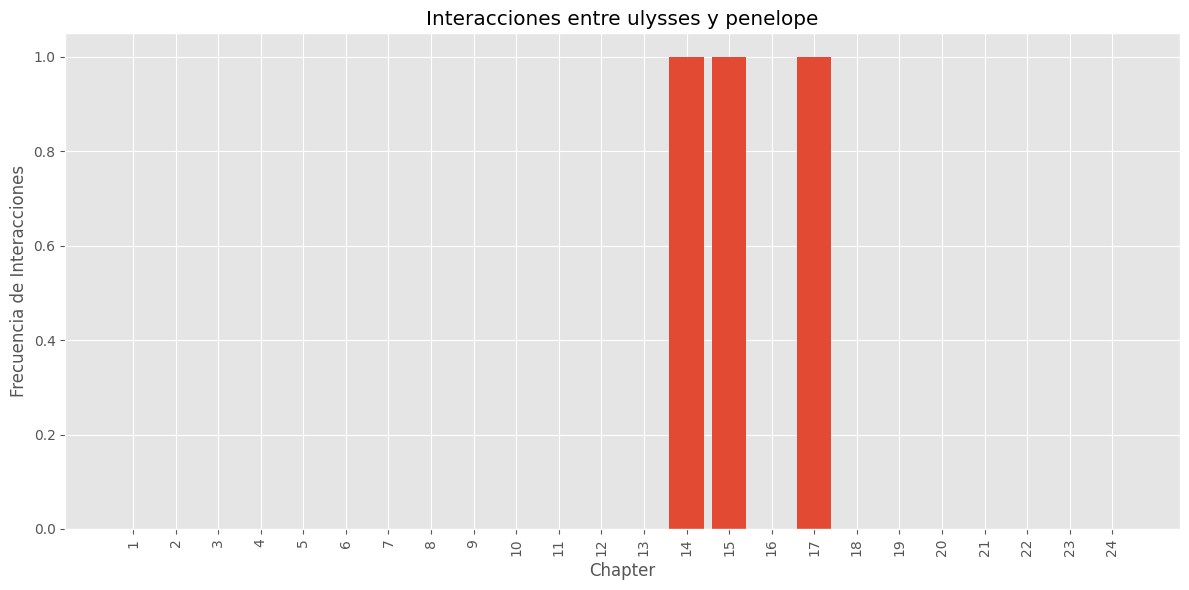

Total interacciones: 3


In [ ]:
graficarInteracciones(dfTripletas,"ulysses","penelope")

In [ ]:
# display(dfTripletas["levelAccion"].value_counts())
# display(dfTripletas["levelAccion"].describe())

##Graficas de diagnostico del modelo
___

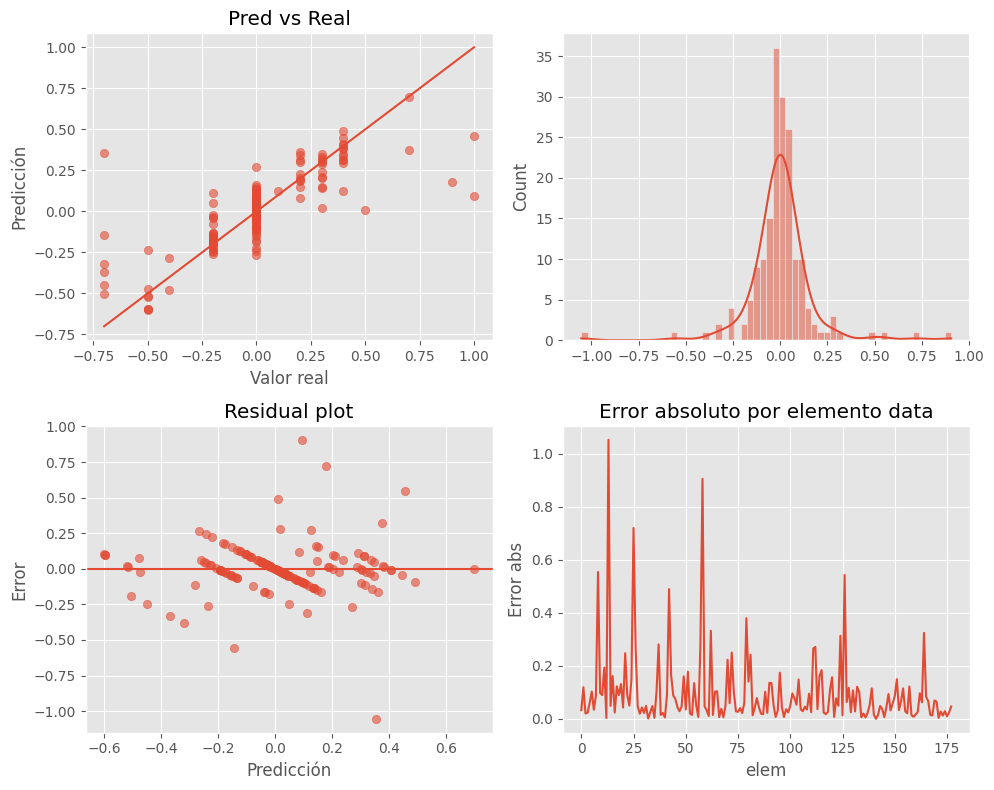

In [ ]:
def graficasModelo(yTest, yPred):
    errores = yTest - yPred
    errorAbs = np.abs(errores)
    fig, ax = plt.subplots(2,2, figsize=(10,8))

    minVal, maxVal = min(yTest.min(), yPred.min()), max(yTest.max(), yPred.max()) # Pred vs Real

    ax[0,0].scatter(yTest, yPred, alpha=0.6)
    ax[0,0].plot([minVal,maxVal],[minVal,maxVal])
    ax[0,0].set(title="Pred vs Real", xlabel="Valor real", ylabel="Predicción")

    sns.histplot(errores, kde=True, ax=ax[0,1])    # Distribución errores

    ax[1,0].scatter(yPred, errores, alpha=0.6)
    ax[1,0].axhline(0)
    ax[1,0].set(title="Residual plot", xlabel="Predicción", ylabel="Error")


    ax[1,1].plot(errorAbs)    # Error absoluto
    ax[1,1].set(title="Error absoluto por elemento data", xlabel="elem", ylabel="Error abs")

    plt.tight_layout()
    plt.show()
graficasModelo(resultado["yTest"], resultado["yPred"])

** Grafica de valores reales vs predichos**

Acontinuacion se realizo una grafica de valores reales con valores predichos, se ve una linea diagonal que los puntos dan una diagonal con algo de dispersion lo que que muestra un patron donde el modelo aprendio con errores pequenos.[link text](https://)

** Grafica de error residual **

Definiendo el Error residual =Yreal -Ypredicho la grafica muestra valores dispersos con valores extremos que deben ser puntos dificiles de predecir.

** Grafica de distribucion de errores **
Como podemos ver tiene forma de campana lo cual es muy buena senal, los errores no tienen un sesgo fuerte.

** Grafica de error absoluto por elemento **
Definiendo el error absoluto como ABS(Yreal - Ypredicho)
La mayoria de los datos estan al rededor de 0.4 con picos ocacionales altos (entre 0.8 y 1) que deben ser algunos casos especiales en el modelo (difisil de predecir). tiene una zona de picos concentrados enre los elementos 0 a 0.25 que representaria que estos elementos es un grupo problematico a analisar.

## Analisis de Sensibilidad
---

Se evaluo la influencia de incluir object pasivo voice en la semantica del modelo y los pronombres peronales. Comparandolos con el R^2.

In [ ]:
def evaluarConfiguracionesPipeline(df, epitetosDic, verbWeights, genderDic):

    combinaciones = list(itertools.product([False, True], [False, True]))

    resultadosResumen = []

    for objectPasiveVoice, personalPronouns in combinaciones:

        resultado = ejecutarPipelineML(
            df4_2, epitetosDic, verbWeights, genderDic,
            fasttextModel,
            objectPasiveVoice=objectPasiveVoice,
            personalPronouns=personalPronouns
        )

        metricas = resultado["metricas"]
        dfTripletas = resultado["dfTripletas"]

        dfTripletas["a"] = dfTripletas["a"].str.lower()
        dfTripletas["b"] = dfTripletas["b"].str.lower()

        ulyssesInteractions = (
            (dfTripletas["a"] == "ulysses") |
            (dfTripletas["b"] == "ulysses")
        ).sum()

        print("\n==============================")
        print(f"objectPasiveVoice = {objectPasiveVoice}")
        print(f"personalPronouns  = {personalPronouns}")
        print("------------------------------")
        print("Interacciones con Ulysses:", ulyssesInteractions)

        resultadosResumen.append({
            "objectPasiveVoice": objectPasiveVoice,
            "personalPronouns": personalPronouns,
            "totalTripletas": len(dfTripletas),
            "ulyssesInteractions": ulyssesInteractions,

            # métricas separadas
            "MAE": metricas["mae"],
            "MSE": metricas["mse"],
            "RMSE": float(metricas["rmse"]),
            "R2": metricas["r2"]
        })

    dfComparacion = pd.DataFrame(resultadosResumen)

    return dfComparacion

In [ ]:
evaluarConfiguracionesPipeline(df4_2, epitetosDic, verbWeights, genderDic)


objectPasiveVoice = False
personalPronouns  = False
------------------------------
Interacciones con Ulysses: 41

objectPasiveVoice = False
personalPronouns  = True
------------------------------
Interacciones con Ulysses: 0

objectPasiveVoice = True
personalPronouns  = False
------------------------------
Interacciones con Ulysses: 160

objectPasiveVoice = True
personalPronouns  = True
------------------------------
Interacciones con Ulysses: 0


,objectPasiveVoice,personalPronouns,totalTripletas,ulyssesInteractions,MAE,MSE,RMSE,R2
0,False,False,79,41,0.156599,0.049854,0.223281,0.169095
1,False,True,12,0,0.328411,0.108092,0.328774,-0.201023
2,True,False,2316,160,0.096507,0.029448,0.171606,0.611302
3,True,True,2311,0,0.097961,0.029097,0.170578,0.573567


Se puede apreciar que el modelo simulado con mejor R^2 es el (2) con objectiPasiveVoice Ture and Personal Pronouns False. Se puede apreciar que este modelo da un numero considerable de interaciones con el personaje principal de la obra (Ulysses) lo que podria considerarse un buen modelo.

In [ ]:
vector_sizes = [50, 100, 150, 200, 300] # valores de vector_size a probar

resultados = []

for v in vector_sizes:

    fasttextModel = entrenarFastText(corpus, vectorSize=v)

    resultado = ejecutarPipelineML(
        df4_2,
        epitetosDic,
        verbWeights,
        genderDic,
        fasttextModel,
        objectPasiveVoice=True,
        personalPronouns=False
    )

    metricas = resultado["metricas"]

    resultados.append({
        "vectorSize": v,
        "MAE": metricas["mae"],
        "MSE": metricas["mse"],
        "RMSE": metricas["rmse"],
        "R2": metricas["r2"]
    })

dfSensibilidad = pd.DataFrame(resultados)
print(dfSensibilidad)

   vectorSize       MAE       MSE      RMSE        R2
0          50  0.095105  0.030245  0.173912  0.600784
1         100  0.095733  0.028851  0.169857  0.619184
2         150  0.097539  0.030476  0.174575  0.597735
3         200  0.097043  0.029609  0.172072  0.609187
4         300  0.094832  0.029321  0.171234  0.612984


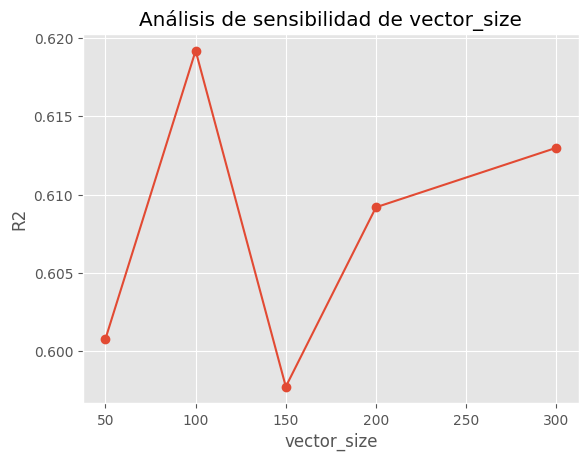

In [ ]:
plt.plot(dfSensibilidad["vectorSize"], dfSensibilidad["R2"], marker="o")
plt.xlabel("vector_size")
plt.ylabel("R2")
plt.title("Análisis de sensibilidad de vector_size")
plt.show()

150Se evaluo la influencia del tamano  del vector en el modelo fastText comparandolo con el R^2. Despues de 100 la calidad baja.
Como esto corre el modelo varias veces es lento.